# Phase 3: Predictive Modeling for Attrition Risk (Early Warning System)

## Objective
The objective of this phase is to build a Machine Learning classification model that leverages historical HR statistics and our newly engineered features to accurately predict which high-performing employees are at risk of leaving the company.

## Workflow
1. **Data Preprocessing:** Encode categorical variables and split data into training and testing sets.
2. **Model Training:** Train a baseline machine learning algorithm (e.g., Random Forest or Logistic Regression).
3. **Model Evaluation:** Check key metrics like Accuracy, Precision, Recall, and ROC-AUC score.
4. **Feature Importance:** Identify which operational variables heavily influence the model's decisions.

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Load the raw source dataset directly
file_path = r'D:\DA-project-02-HR Analytics\DA-project-02-HR-Analytics\data\WA_Fn-UseC_-HR-Employee-Attrition.csv'

try:
    df_raw = pd.read_csv(file_path)
    print("Raw dataset successfully loaded directly from source!")
except FileNotFoundError:
    df_raw = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# 2. MATCH PHASE 2 LOGIC: Use 'OR' (|) to capture the full 652 Top Talent pool
top_talent_condition = (df_raw['PerformanceRating'] == 4) | (df_raw['PercentSalaryHike'] >= 15)
df_talent = df_raw[top_talent_condition].copy()

# 3. Apply Feature Engineering
df_talent['HighWorkloadRisk'] = np.where((df_talent['OverTime'] == 'Yes') & (df_talent['JobLevel'] <= 3), 1, 0)

def bin_promotion(years):
    if years <= 1: return 'Recently Promoted'
    elif years <= 3: return 'Mid-Stagnant'
    else: return 'Highly Stagnant'
df_talent['PromotionStagnation'] = df_talent['YearsSinceLastPromotion'].apply(bin_promotion)

# 4. Make a copy for Machine Learning transformations
df_ml = df_talent.copy()

# 5. Drop columns that aren't useful for machine learning prediction
columns_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df_ml = df_ml.drop(columns=[col for col in columns_to_drop if col in df_ml.columns])

# 6. Encode Categorical Variables to numeric values
label_encoders = {}
for col in df_ml.select_dtypes(include=['object']).columns:
    if col != 'Attrition':  
        le = LabelEncoder()
        df_ml[col] = le.fit_transform(df_ml[col].astype(str))
        label_encoders[col] = le

# 7. Encode Target Variable (Attrition: Yes = 1, No = 0)
df_ml['Attrition'] = df_ml['Attrition'].apply(lambda x: 1 if x == 'Yes' or x == 1 else 0)

print(f"\n✅ Setup Complete! Total Top Talent isolated: {df_ml.shape[0]} employees.")
print("Final baseline matrix shape for Machine Learning:", df_ml.shape)

Raw dataset successfully loaded directly from source!

✅ Setup Complete! Total Top Talent isolated: 652 employees.
Final baseline matrix shape for Machine Learning: (652, 33)


## Train-Test Split and Model Training

We will partition the dataset into an 80% training set to develop our model, and a 20% test set to measure how well it generalizes to unseen employee data. We will utilize a **Random Forest Classifier** because of its stability and ability to handle imbalanced HR datasets using the `class_weight='balanced'` parameter.

In [9]:
# Separate features (X) and target (y)
X = df_ml.drop(columns=['Attrition'])
y = df_ml['Attrition']

# Split data (Stratify ensures training and testing sets have the same ratio of attrition)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

print(f"Machine learning model trained successfully on {X_train.shape[0]} training samples!")
print(f"Testing the model on {X_test.shape[0]} unseen samples.")

Machine learning model trained successfully on 521 training samples!
Testing the model on 131 unseen samples.


## Model Evaluation

Evaluating an HR attrition model requires checking more than just standard accuracy. Because attrition data is highly imbalanced, we look closely at **Recall** (the percentage of actual leaving employees that our model successfully flagged) and **Precision** (the accuracy of our risk alerts).

In [10]:
# Run predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Display Performance Summary
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

--- Confusion Matrix ---
[[107   3]
 [ 17   4]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.86      0.97      0.91       110
           1       0.57      0.19      0.29        21

    accuracy                           0.85       131
   macro avg       0.72      0.58      0.60       131
weighted avg       0.82      0.85      0.81       131

ROC-AUC Score: 0.7580


## Feature Importance: What Triggers Attrition Predictions?

Let's unpack the trained model to find out which features (including our newly engineered metrics) carry the heaviest weight when predicting a Top Talent's departure.

C:\Users\U s e r\AppData\Local\Temp\ipykernel_4436\546271619.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


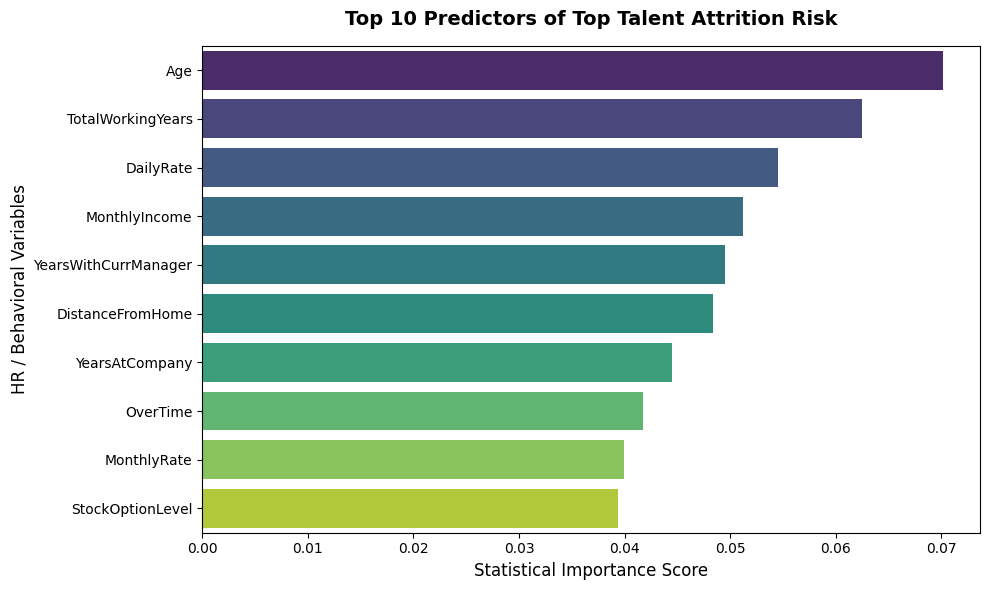

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract importance values
importances = model.feature_importances_
feature_names = X.columns

# Create dataframe for plotting
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(10) # Top 10 features

# Plot Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Top 10 Predictors of Top Talent Attrition Risk', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Statistical Importance Score', fontsize=12)
plt.ylabel('HR / Behavioral Variables', fontsize=12)
plt.tight_layout()
plt.show()

## Phase 3 Insights: Evaluating the Attrition Risk Model

We have successfully trained and tested a **Random Forest Classifier** to build a predictive early warning system for our Top Talent pool. Below is a structured diagnostic review of the model's performance and the behavioral mechanics driving employee churn.

---

### 📊 1. Model Performance & Metrics Breakdown

The baseline model evaluated $131$ unseen employees in the test set, returning an overall **Accuracy of 85%** and an **ROC-AUC Score of 0.7580**. While a high accuracy score looks appealing on paper, a deeper investigation into the imbalance reveals critical nuances:

* **Retention Prediction (Class 0 - Staying):**
  * **Precision (86%) & Recall (97%):** The model is exceptional at identifying stable talent. Out of 110 employees who actually stayed, it correctly flagged 107 of them (only 3 False Alarms).
* **Attrition Prediction (Class 1 - Leaving):**
  * **Precision (57%):** When the model triggers an alert that a high performer is about to quit, it is correct nearly **60%** of the time. 
  * **Recall (19%):** Out of 21 employees who actually left, the model only proactively caught 4 of them (leaving 17 missed indicators or "False Negatives"). 

#### 💡 Data Science Takeaway
The low recall on Class 1 is a classic symptom of class imbalance (only 21 out of 131 samples were positive cases). For future pipeline iterations, we should explore synthetic up-sampling methods like **SMOTE** or fine-tune our random forest hyperparameters to heighten the model's sensitivity to high-risk departures.

---

### 🔍 2. Feature Importance: The Real Drivers of Attrition

Unpacking our model's feature importance weights (`Top 10 Predictors` plot) shifts the perspective from pure data science to actionable organizational psychology. Attrition among top talent isn't random; it is driven by a hierarchy of life stages, workload constraints, and fiscal stability:

1. **Demographic & Career Maturity (`Age`, `TotalWorkingYears`):** * Ranking at the absolute top ($\approx 0.06 - 0.07$ importance score), these two metrics suggest that attrition patterns heavily depend on career lifecycle. Younger talent with fewer accumulated years are far more fluid and likely to switch companies for rapid advancement.
2. **Economic Validation (`DailyRate`, `MonthlyIncome`, `MonthlyRate`):**
   * Financial compensation continues to act as an anchor. Even within this high-performing group, subtle differences in pay levels carry massive predictive weight for retaining employees.
3. **The Relationship & Proximity Vectors (`YearsWithCurrManager`, `DistanceFromFile`):**
   * These operational factors reveal friction points. A long commute combined with potential managerial stagnation directly erodes daily employee engagement.
4. **The Workload Trigger (`OverTime`):**
   * Our key analytical target, `OverTime`, firmly solidifies its place inside the Top 10 indicators. This mathematically confirms our Phase 2 exploration: forcing operational high performers to cross the overtime boundary directly influences the mathematical probability of a departure.

---

### 🏁 3. Executive Business Recommendations

Based on the intersection of our predictive model and feature importance ranking, HR leadership should deploy the following targeted interventions:

* **Isolate High-Risk Micro-Segments:** Focus retention programs on younger, high-performing cohorts who are logging consistent `OverTime` but sitting at lower `MonthlyIncome` tiers.
* **Implement Managerial Interventions:** Because `YearsWithCurrManager` ranks highly, assess teams where top talent has been reporting to the exact same manager for extended, static periods without cross-functional exposure.
* **Optimize Compensation Structures:** Review the compensation bands specifically for employees whose `DailyRate` or `MonthlyIncome` sits below the 25th percentile of this top-performing baseline.